In [2]:
import pandas as pd

customers = pd.read_csv("../dataset/olist_customers_dataset.csv")
orders = pd.read_csv("../dataset/olist_orders_dataset.csv")
payments = pd.read_csv("../dataset/olist_order_payments_dataset.csv")
products = pd.read_csv("../dataset/olist_products_dataset.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)
Products: (32951, 9)


In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
print("Customers Shape:", customers.shape)
print("\nColumns:")
print(customers.columns)

print("\nMissing Values:")
print(customers.isnull().sum())

Customers Shape: (99441, 5)

Columns:
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [5]:
print("Orders Shape:", orders.shape)

print("\nOrders Columns:")
print(orders.columns)

print("\nMissing Values:")
print(orders.isnull().sum())

Orders Shape: (99441, 8)

Orders Columns:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [6]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<Axes: xlabel='order_status'>

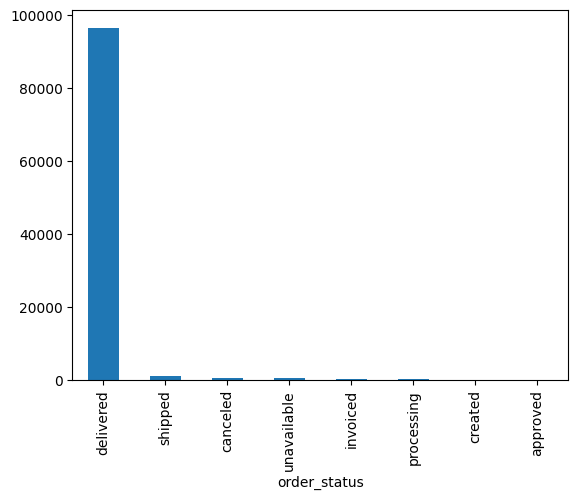

In [7]:
orders['order_status'].value_counts().plot(kind='bar')

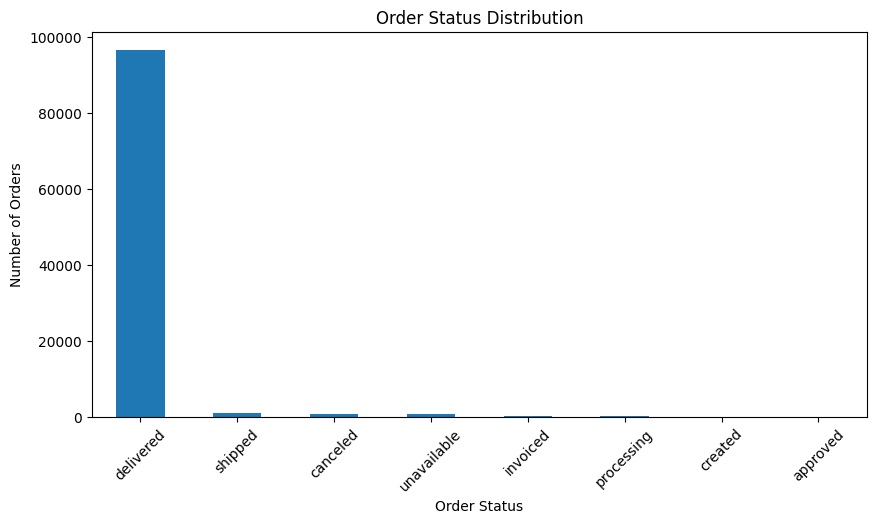

In [8]:
import matplotlib.pyplot as plt

orders['order_status'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [9]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [10]:
print("Payments Shape:", payments.shape)

print("\nPayment Types:")
print(payments['payment_type'].value_counts())

print("\nTotal Revenue:")
print(payments['payment_value'].sum())

Payments Shape: (103886, 5)

Payment Types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Total Revenue:
16008872.120000001


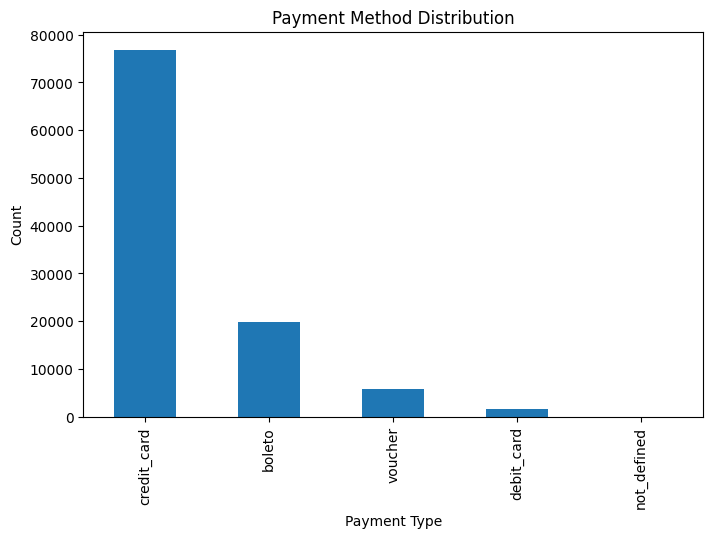

In [11]:
payments['payment_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


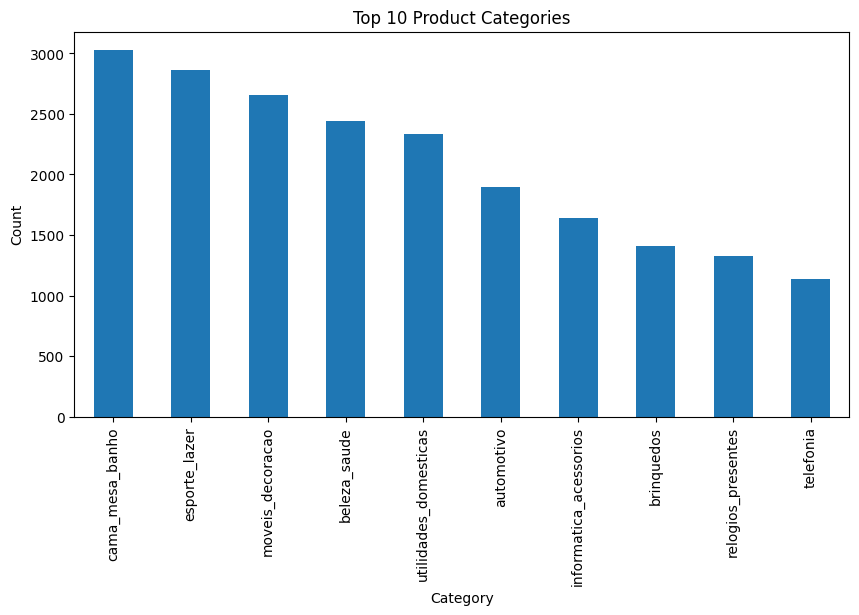

In [12]:
top_products = products['product_category_name'].value_counts().head(10)

print(top_products)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

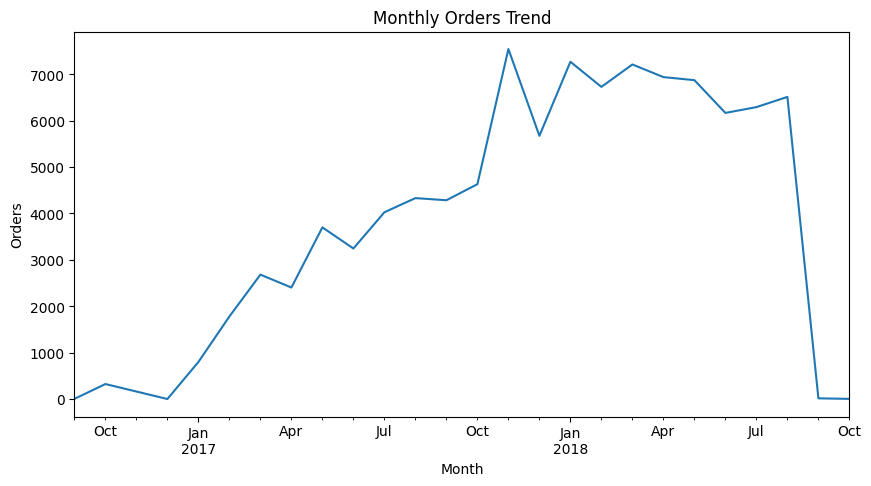

In [13]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

monthly_orders = orders.groupby(
    orders['order_purchase_timestamp'].dt.to_period('M')
).size()

monthly_orders.plot(figsize=(10,5))
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

Total Revenue: 16008872.120000001


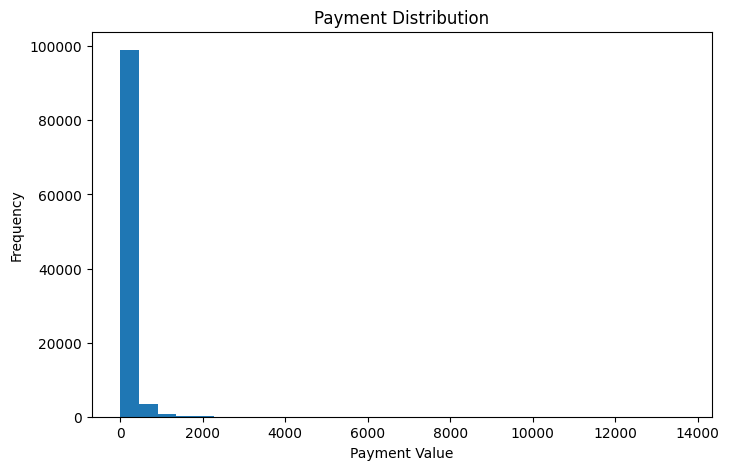

In [14]:
print("Total Revenue:", payments['payment_value'].sum())

payments['payment_value'].plot(
    kind='hist',
    bins=30,
    figsize=(8,5)
)

plt.title("Payment Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()

In [15]:
import pandas as pd

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Latest date
snapshot_date = orders['order_purchase_timestamp'].max()

# RFM Calculation
rfm = orders.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count'
})

rfm.columns = ['Recency', 'Frequency']

rfm.head()

,Recency,Frequency
customer_id,,
00012a2ce6f8dcda20d059ce98491703,337,1
000161a058600d5901f007fab4c27140,458,1
0001fd6190edaaf884bcaf3d49edf079,596,1
0002414f95344307404f0ace7a26f1d5,427,1
000379cdec625522490c315e70c7a9fb,198,1


In [16]:
order_payment = pd.merge(
    orders[['order_id','customer_id']],
    payments[['order_id','payment_value']],
    on='order_id'
)

monetary = order_payment.groupby(
    'customer_id'
)['payment_value'].sum()

rfm['Monetary'] = monetary

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,337,1,114.74
000161a058600d5901f007fab4c27140,458,1,67.41
0001fd6190edaaf884bcaf3d49edf079,596,1,195.42
0002414f95344307404f0ace7a26f1d5,427,1,179.35
000379cdec625522490c315e70c7a9fb,198,1,107.01


In [17]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,337,1,114.74,2,1,3,213.0
000161a058600d5901f007fab4c27140,458,1,67.41,1,1,2,112.0
0001fd6190edaaf884bcaf3d49edf079,596,1,195.42,1,1,4,114.0
0002414f95344307404f0ace7a26f1d5,427,1,179.35,1,1,4,114.0
000379cdec625522490c315e70c7a9fb,198,1,107.01,3,1,3,313.0


In [18]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Champion'
    elif row['R_Score'] == 4:
        return 'Loyal Customer'
    elif row['R_Score'] == 1:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

Segment
Regular           49623
Loyal Customer    25124
At Risk           24694
Name: count, dtype: int64

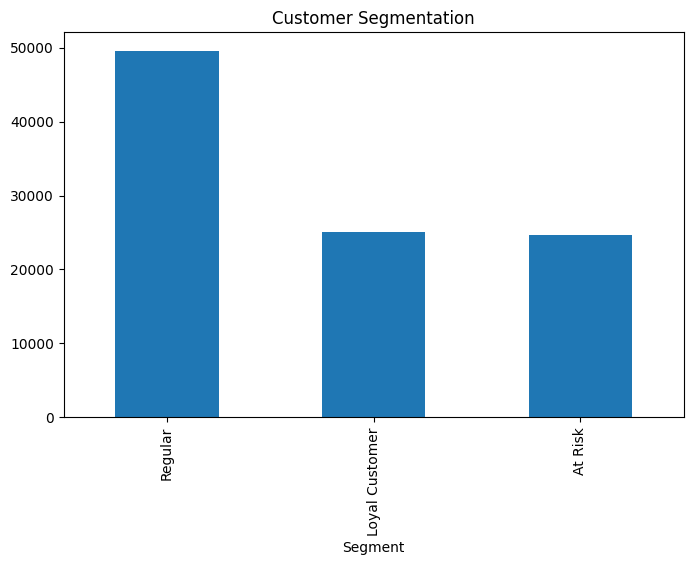

In [19]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Customer Segmentation")
plt.show()

In [20]:
snapshot_date = orders['order_purchase_timestamp'].max()

rfm['Churn'] = rfm['Recency'].apply(
    lambda x: 1 if x > 180 else 0
)

rfm[['Recency','Frequency','Monetary','Churn']].head()

,Recency,Frequency,Monetary,Churn
customer_id,,,,
00012a2ce6f8dcda20d059ce98491703,337,1,114.74,1
000161a058600d5901f007fab4c27140,458,1,67.41,1
0001fd6190edaaf884bcaf3d49edf079,596,1,195.42,1
0002414f95344307404f0ace7a26f1d5,427,1,179.35,1
000379cdec625522490c315e70c7a9fb,198,1,107.01,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [22]:
rfm['Predicted_Churn'] = model.predict(X)

high_risk = rfm[
    rfm['Predicted_Churn'] == 1
]

print("High Risk Customers:")
print(high_risk.head())

High Risk Customers:
                                  Recency  Frequency  Monetary R_Score  \
customer_id                                                              
00012a2ce6f8dcda20d059ce98491703      337          1    114.74       2   
000161a058600d5901f007fab4c27140      458          1     67.41       1   
0001fd6190edaaf884bcaf3d49edf079      596          1    195.42       1   
0002414f95344307404f0ace7a26f1d5      427          1    179.35       1   
000379cdec625522490c315e70c7a9fb      198          1    107.01       3   

                                 F_Score M_Score RFM_Score  Segment  Churn  \
customer_id                                                                  
00012a2ce6f8dcda20d059ce98491703       1       3     213.0  Regular      1   
000161a058600d5901f007fab4c27140       1       2     112.0  At Risk      1   
0001fd6190edaaf884bcaf3d49edf079       1       4     114.0  At Risk      1   
0002414f95344307404f0ace7a26f1d5       1       4     114.0  At Risk   

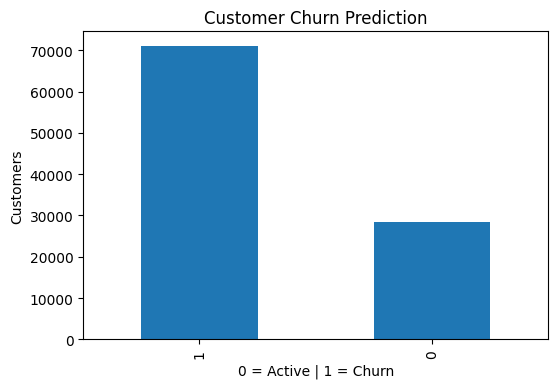

In [23]:
import matplotlib.pyplot as plt

rfm['Predicted_Churn'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Customer Churn Prediction")
plt.xlabel("0 = Active | 1 = Churn")
plt.ylabel("Customers")
plt.show()

In [24]:
monthly_sales = orders.groupby(
    orders['order_purchase_timestamp'].dt.to_period('M')
).size()

monthly_sales = monthly_sales.reset_index()

monthly_sales.columns = ['Month', 'Orders']

monthly_sales.head()

,Month,Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [25]:
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

monthly_sales['Month'] = pd.to_datetime(
    monthly_sales['Month']
)

monthly_sales['Month_Number'] = range(
    len(monthly_sales)
)

monthly_sales.head()

,Month,Orders,Month_Number
0,2016-09-01,4,0
1,2016-10-01,324,1
2,2016-12-01,1,2
3,2017-01-01,800,3
4,2017-02-01,1780,4


In [26]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[['Month_Number']]
y = monthly_sales['Orders']

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
future = pd.DataFrame({
    'Month_Number': range(
        len(monthly_sales),
        len(monthly_sales)+6
    )
})

future['Predicted_Orders'] = model.predict(future)

future

,Month_Number,Predicted_Orders
0,25,6477.160000
1,26,6669.430769
2,27,6861.701538
3,28,7053.972308
4,29,7246.243077
5,30,7438.513846


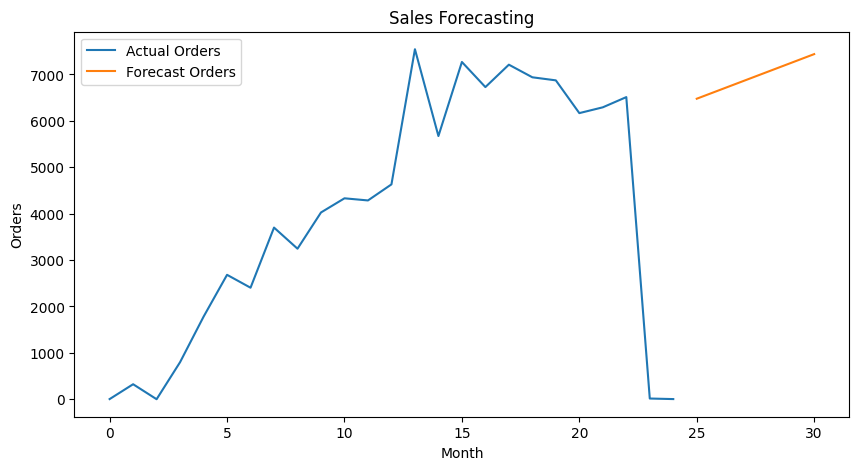

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Orders'],
    label='Actual Orders'
)

plt.plot(
    future['Month_Number'],
    future['Predicted_Orders'],
    label='Forecast Orders'
)

plt.title("Sales Forecasting")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.legend()

plt.show()

In [29]:
from sklearn.cluster import KMeans

customer_segment = customers[['customer_zip_code_prefix']].copy()

kmeans = KMeans(n_clusters=4, random_state=42)
customer_segment['Cluster'] = kmeans.fit_predict(customer_segment)

customer_segment.head()

,customer_zip_code_prefix,Cluster
0,14409,3
1,9790,3
2,1151,3
3,8775,3
4,13056,3
